# Cardiometabolic Conditions and Patterns of Medication Initiation
Which pts had MI, CHF, arrythmia, PVD, CVD, DM and which agents were they more likely to be started on? Did any of these factors make it more likely to start meds for HTN, HLD or DM?

- MI: Myocardial Infarction
- CHF: Congestive Heart Failure
- Arrythmia: Abnormal Heart Rhythm
- PVD: Peripheral Vascular Disease
- CVD: Cardiovascular Disease
- DM: Diabetes Mellitus
- HTN: Hyptertension (high blood pressure)
- HLD: Hyperlipidemia (high cholesterol)

## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy.stats import chi2_contingency


seed = 42
n_folds = 5
df = pd.read_csv('../../data/processed/cardio_onc_prostate_06_broad_clean.csv')

## Data

In [9]:
df = df.copy()
df = df[df["bp_meds_post"].notna()].copy()
df.shape

df["bp_meds_post_bin"] = (df["bp_meds_post"] > 0).astype(int)
df["lipid_meds_post_bin"] = (df["lipid_meds_post"] > 0).astype(int)
df["dm_meds_post_bin"] = (df["dm_meds_post"] > 0).astype(int)

# clean ADT
df["adt_clean"] = (
    df["adt_agent"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"lupon": "lupron", "lpron": "lupron"})
)

main_adt_agents = ["lupron", "firmagon", "orgovyx", "bicalutamide"]

def extract_main_adt(text):
    for agent in main_adt_agents:
        if agent in str(text):
            return agent
    return "other"

df["adt_grouped"] = df["adt_clean"].apply(extract_main_adt)

In [10]:
# predictors
predictors = [
    "hx_cad",
    "hx_chf",
    "hx_arrhythmia",
    "hx_pad",
    "hx_cva",
    "hx_dm2"
]

X_base = df[predictors].copy()
for col in predictors:
    X_base[col] = (X_base[col] == 1).astype(int)

# logistic model
def run_logit(df, X, outcome):

    y = (df[outcome] > 0).astype(int)

    X_model = sm.add_constant(X)

    model = sm.Logit(y, X_model)
    result = model.fit(disp=0)

    summary_df = pd.DataFrame({
        "feature": result.params.index,
        "coef": result.params.values,
        "odds_ratio": np.exp(result.params.values),
        "p_value": result.pvalues.values
    })

    return result, summary_df.sort_values("odds_ratio", ascending=False)

## Which patients had MI, CHF, Arrythmia, PVD, CVD, DM?

Prevalence of Pre existing Conditions:
hx_dm2_bin           29.7%
hx_cad_bin           17.8%
hx_arrhythmia_bin    12.4%
hx_chf_bin            5.9%
hx_cva_bin            5.0%
hx_pad_bin            3.0%
dtype: str


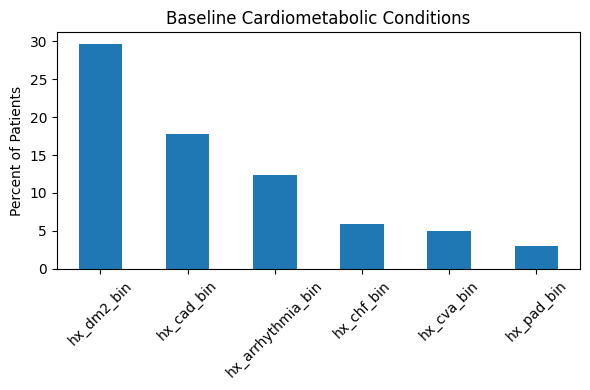

In [11]:
for col in predictors:
    df[col + "_bin"] = (df[col] == 1).astype(int)

# Prevalence
prev = df[[c + "_bin" for c in predictors]].mean().sort_values(ascending=False)

print("Prevalence of Pre existing Conditions:")
print((prev * 100).round(1).astype(str) + "%")

plt.figure(figsize=(6,4))

(prev * 100).plot(kind="bar")

plt.title("Baseline Cardiometabolic Conditions")
plt.ylabel("Percent of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Which agents were they more likely to be started on?

### NHT

In [12]:
for col in predictors:
    print(f"\n--- {col} vs NHT ---")
    
    ct = pd.crosstab(
        df[col + "_bin"],
        df["specific_nht_used"],
        normalize="index"
    )
    
    print(ct)


--- hx_cad vs NHT ---
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
hx_cad_bin                                                             
0                     0.463855     0.066265      0.385542      0.084337
1                     0.333333     0.055556      0.472222      0.138889

--- hx_chf vs NHT ---
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
hx_chf_bin                                                             
0                     0.442105     0.063158      0.405263      0.089474
1                     0.416667     0.083333      0.333333      0.166667

--- hx_arrhythmia vs NHT ---
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
hx_arrhythmia_bin                                                      
0                     0.446328     0.062147      0.418079      0.073446
1                     0.400000     0.080000      0.280000      0.240000

--- hx_pad vs NHT ---
specific_nht_used  Abiraterone  Apalu

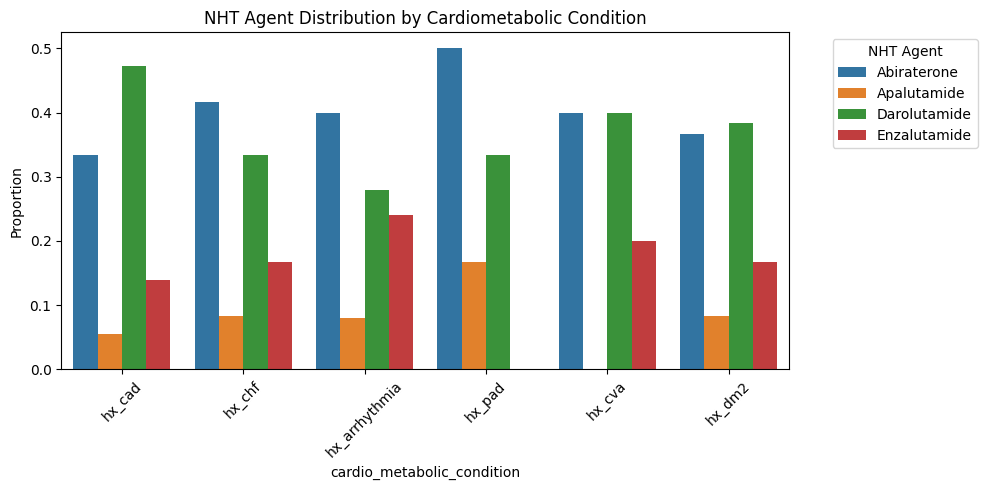

In [13]:
plot_data = []

for col in predictors:
    temp = pd.crosstab(
        df[col + "_bin"],
        df["specific_nht_used"],
        normalize="index"
    ).reset_index()

    temp["cardio_metabolic_condition"] = col
    temp = temp[temp[col + "_bin"] == 1]

    temp = temp.drop(columns=[col + "_bin"])
    plot_data.append(temp)

plot_df = pd.concat(plot_data)

plot_df = plot_df.melt(
    id_vars="cardio_metabolic_condition",
    var_name="NHT_agent",
    value_name="proportion"
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="cardio_metabolic_condition",
    y="proportion",
    hue="NHT_agent"
)

plt.title("NHT Agent Distribution by Cardiometabolic Condition")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="NHT Agent", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
for col in predictors:
    ct = pd.crosstab(df[col + "_bin"], df["specific_nht_used"])
    
    chi2, p, _, _ = chi2_contingency(ct)
    
    print(f"{col} vs NHT p-value: {p:.4f}")

hx_cad vs NHT p-value: 0.4425
hx_chf vs NHT p-value: 0.8137
hx_arrhythmia vs NHT p-value: 0.0522
hx_pad vs NHT p-value: 0.6353
hx_cva vs NHT p-value: 0.5783
hx_dm2 vs NHT p-value: 0.0942


### Summary
Across baseline cardiometabolic conditions, there were no statistically significant associations between condition status and selection of novel hormonal therapy (NHT) agents. Coronary artery disease, congestive heart failure, peripheral arterial disease, cerebrovascular disease, and diabetes were not associated with differences in NHT selection (all p > 0.05). A borderline association was observed for arrhythmia (p = 0.052) and diabetes (p = 0.094), suggesting a possible trend toward differential prescribing in these subgroups; however, these findings did not reach statistical significance. Overall, these results indicate that NHT agent selection was largely consistent across condition profiles, with no strong evidence that baseline cardiometabolic risk influenced choice of therapy.

### ADT

In [15]:
for col in predictors:
    print(f"\n--- {col} vs ADT ---")
    
    ct = pd.crosstab(
        df[col + "_bin"],
        df["adt_grouped"],
        normalize="index"
    )
    
    print(ct)


--- hx_cad vs ADT ---
adt_grouped  bicalutamide  firmagon    lupron   orgovyx     other
hx_cad_bin                                                       
0                0.114458  0.078313  0.289157  0.451807  0.066265
1                0.222222  0.111111  0.472222  0.166667  0.027778

--- hx_chf vs ADT ---
adt_grouped  bicalutamide  firmagon    lupron   orgovyx     other
hx_chf_bin                                                       
0                0.126316  0.084211  0.310526  0.415789  0.063158
1                0.250000  0.083333  0.500000  0.166667  0.000000

--- hx_arrhythmia vs ADT ---
adt_grouped        bicalutamide  firmagon    lupron   orgovyx     other
hx_arrhythmia_bin                                                      
0                      0.135593  0.090395  0.299435  0.412429  0.062147
1                      0.120000  0.040000  0.480000  0.320000  0.040000

--- hx_pad vs ADT ---
adt_grouped  bicalutamide  firmagon    lupron   orgovyx     other
hx_pad_bin         

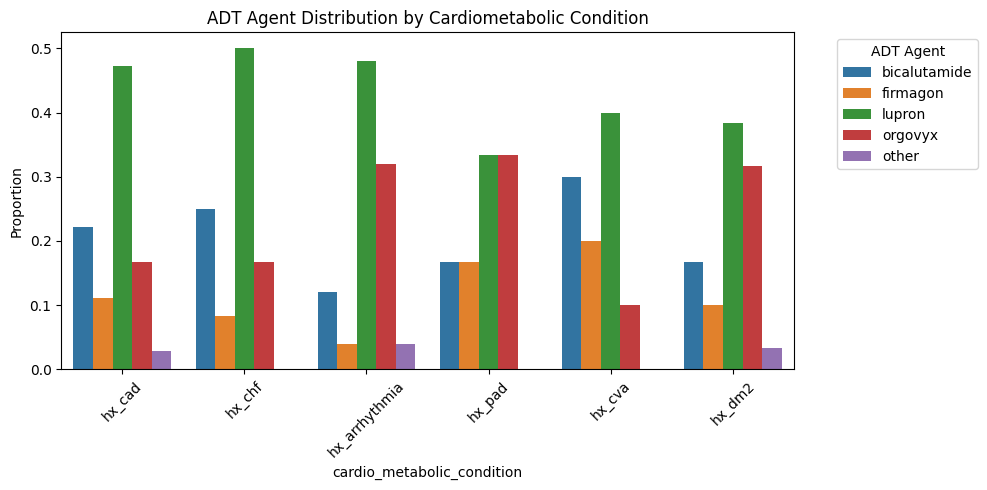

In [16]:
plot_data = []

for col in predictors:
    temp = pd.crosstab(
        df[col + "_bin"],
        df["adt_grouped"],
        normalize="index"
    ).reset_index()

    temp["cardio_metabolic_condition"] = col
    temp = temp[temp[col + "_bin"] == 1]  # only patients WITH condition

    temp = temp.drop(columns=[col + "_bin"])
    plot_data.append(temp)

plot_df = pd.concat(plot_data)

# Melt for plotting
plot_df = plot_df.melt(
    id_vars="cardio_metabolic_condition",
    var_name="ADT_agent",
    value_name="proportion"
)

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="cardio_metabolic_condition",
    y="proportion",
    hue="ADT_agent"
)

plt.title("ADT Agent Distribution by Cardiometabolic Condition")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="ADT Agent", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [17]:
for col in predictors:
    ct = pd.crosstab(df[col + "_bin"], df["adt_grouped"])
    
    chi2, p, _, _ = chi2_contingency(ct)
    
    print(f"{col} vs ADT p-value: {p:.4f}")

hx_cad vs ADT p-value: 0.0125
hx_chf vs ADT p-value: 0.2816
hx_arrhythmia vs ADT p-value: 0.4676
hx_pad vs ADT p-value: 0.9111
hx_cva vs ADT p-value: 0.1329
hx_dm2 vs ADT p-value: 0.3491


### Summary
A statistically significant association was observed between coronary artery disease (CAD) and selection of androgen deprivation therapy (ADT) agents (p = 0.0125), suggesting that patients with CAD may have been preferentially treated with certain ADT regimens. No other conditions—including congestive heart failure, arrhythmia, peripheral arterial disease, cerebrovascular disease, or diabetes—were significantly associated with ADT selection (all p > 0.05). Despite the significant finding for CAD, differences in agent distribution were modest, and the overall pattern suggests limited clinical impact. Taken together, these results indicate that while ADT selection may be modestly influenced by the presence of CAD, most baseline cardiometabolic conditions do not appear to meaningfully drive treatment choice.

## CAD and ADT Analysis

In [18]:
ct_prop = pd.crosstab(
    df["hx_cad_bin"],
    df["adt_grouped"],
    normalize="index"
)

print(ct_prop)
diff = ct_prop.loc[1] - ct_prop.loc[0]
diff = diff.sort_values(ascending=False)

print(diff)

ct = pd.crosstab(df["hx_cad_bin"], df["adt_grouped"])
chi2, p, _, _ = chi2_contingency(ct)

n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print("Cramér’s V:", cramers_v)

expected = chi2_contingency(ct)[3]
residuals = (ct - expected) / np.sqrt(expected)

residuals_df = pd.DataFrame(
    residuals,
    index=ct.index,
    columns=ct.columns
)

print(residuals_df)

adt_grouped  bicalutamide  firmagon    lupron   orgovyx     other
hx_cad_bin                                                       
0                0.114458  0.078313  0.289157  0.451807  0.066265
1                0.222222  0.111111  0.472222  0.166667  0.027778
adt_grouped
lupron          0.183066
bicalutamide    0.107764
firmagon        0.032798
other          -0.038487
orgovyx        -0.285141
dtype: float64
Cramér’s V: 0.251390593645822
adt_grouped  bicalutamide  firmagon    lupron   orgovyx     other
hx_cad_bin                                                       
0               -0.676822 -0.259598 -0.741022  1.033945  0.362583
1                1.453373  0.557448  1.591233 -2.220241 -0.778593


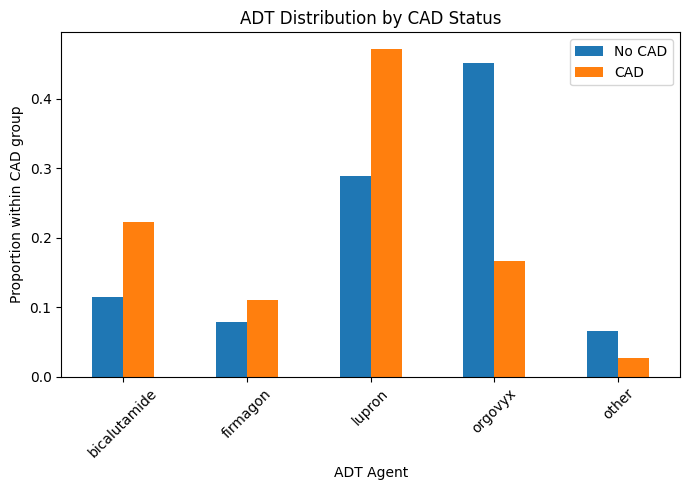

In [19]:
ct_prop.T.plot(kind="bar", figsize=(7,5))

plt.title("ADT Distribution by CAD Status")
plt.ylabel("Proportion within CAD group")
plt.xlabel("ADT Agent")
plt.legend(["No CAD", "CAD"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary
A statistically significant association was observed between coronary artery disease (CAD) and selection of androgen deprivation therapy (ADT) agents (p = 0.0125), with a moderate effect size (Cramér’s V = 0.25). Patients without CAD were most commonly treated with Orgovyx (45.2%), whereas those with CAD were more frequently treated with Lupron (47.2%) and substantially less likely to receive Orgovyx (16.7%), representing a 28.5 percentage point decrease. This shift was the primary driver of the observed association, as confirmed by standardized residual analysis demonstrating significant underrepresentation of Orgovyx among CAD patients (residual = −2.22). In contrast, increased use of Lupron and bicalutamide among CAD patients was more modest and did not independently account for the statistical significance. Overall, these findings suggest that CAD status is associated with a meaningful shift in ADT selection, characterized primarily by reduced use of Orgovyx and compensatory increases in alternative agents, potentially reflecting clinician prescribing preferences or perceived cardiovascular risk considerations.

## Did MI, CHF, Arrythmia, PVD, CVD, DM make it more likely to start meds for HTN, HLD, or DM?

## Model 1: BP Medication Escalation

In [20]:
bp_result, bp_summary = run_logit(df, X_base, "bp_meds_post_bin")
bp_summary

,feature,coef,odds_ratio,p_value
2,hx_chf,1.303583,3.682467,7.088755e-02
5,hx_cva,1.085032,2.959536,1.558796e-01
6,hx_dm2,0.107971,1.114016,7.922592e-01
4,hx_pad,-0.082219,0.921070,9.440761e-01
1,hx_cad,-0.194367,0.823356,7.148455e-01
3,hx_arrhythmia,-0.228549,0.795687,7.230233e-01
0,const,-1.636813,0.194599,1.193000e-11


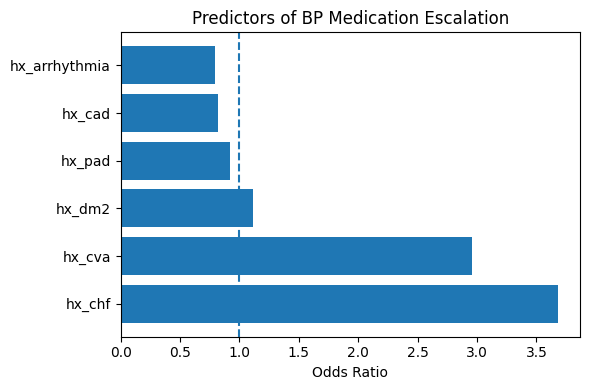

In [21]:
plot_df = bp_summary[bp_summary["feature"] != "const"]

plt.figure(figsize=(6,4))
plt.barh(plot_df["feature"], plot_df["odds_ratio"])
plt.axvline(1, linestyle="--")
plt.title("Predictors of BP Medication Escalation")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()

### Summary
Patients with MI, CHF, Arrythmia, PVD, CVD, or DM, did not have statistically significant associations with the initaitioon of blood pressure medications following NHT. While some conditions showed a modest increase in odds of BP medication esccalation, these effects were not statistically robust. baseline diabetes also was not a strong predictor in this model. Overall this suggests that hypertension management after NHT may be more influenced by clinical monitoring or acute blood pressure changes rather than pre existing cardiovascular disease. 

## Model 2: Lipid Medication Escalation

In [22]:
lipid_result, lipid_summary = run_logit(df, X_base, "lipid_meds_post_bin")
lipid_summary

,feature,coef,odds_ratio,p_value
4,hx_pad,0.993461,2.700566,3.050896e-01
1,hx_cad,0.830008,2.293338,1.080580e-01
5,hx_cva,0.816010,2.261459,3.728190e-01
6,hx_dm2,-0.118344,0.888390,8.003922e-01
3,hx_arrhythmia,-0.535572,0.585334,4.860600e-01
2,hx_chf,-0.890927,0.410275,4.379392e-01
0,const,-1.956210,0.141393,6.923171e-13


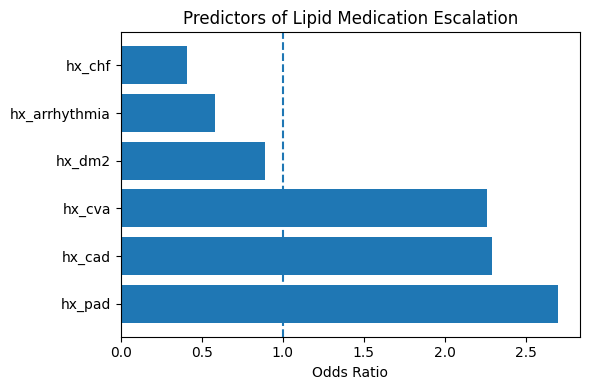

In [23]:
plot_df = lipid_summary[lipid_summary["feature"] != "const"]

plt.figure(figsize=(6,4))
plt.barh(plot_df["feature"], plot_df["odds_ratio"])
plt.axvline(1, linestyle="--")
plt.title("Predictors of Lipid Medication Escalation")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()

### Summary
Baseline cardiovascular conditions did not have a significant association with the initiation of lipid lowering therapy after NHT. Patients with prior cornorary artery disease or peripheral vascular disease did have slight increases in odds of lipid medication initiation, but these associations were not statistically significant. Baseline diabetes also didn't demonstrate a strong relationship with lipid medication escalation. This suggests that lipiod management following NHT isn't strongly related by pre existing cardiovascular conditions.

## Model 3: DM Medication Escalation

In [24]:
dm_result, dm_summary = run_logit(df, X_base, "dm_meds_post_bin")
dm_summary

,feature,coef,odds_ratio,p_value
6,hx_dm2,1.094870,2.988795,3.914023e-03
5,hx_cva,0.909030,2.481914,2.989374e-01
1,hx_cad,0.341873,1.407581,4.933558e-01
4,hx_pad,0.070979,1.073558,9.512788e-01
2,hx_chf,-1.103462,0.331721,3.351703e-01
3,hx_arrhythmia,-1.415783,0.242736,9.893187e-02
0,const,-1.699790,0.182722,1.267973e-11


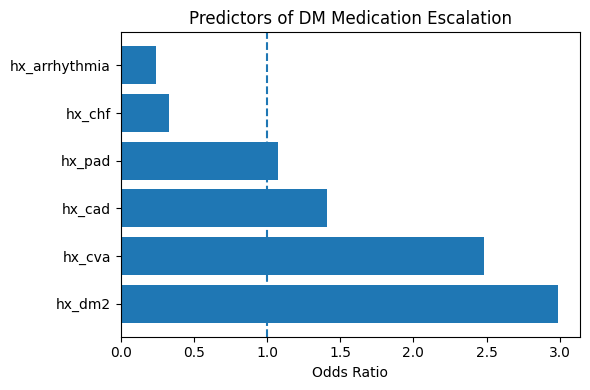

In [25]:
plot_df = dm_summary[dm_summary["feature"] != "const"]

plt.figure(figsize=(6,4))
plt.barh(plot_df["feature"], plot_df["odds_ratio"])
plt.axvline(1, linestyle="--")
plt.title("Predictors of DM Medication Escalation")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.show()

### Summary
Baseline metabolic disease demonstrated a stronger relationship with diabetes medication initiation. Patients with pre existing diabetes had increased odds of starting new DM meds after NHT. Other CV conditions like CAD, CHF, arrhythmia, PAD, and CVA did not have signficant association with new DM medications. This indicates that glycemic management after NHT is driven by underlying metabolic risk.

In [26]:
for col in predictors:
    ct = pd.crosstab(df[col], df["dm_meds_post_bin"])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{col} vs DM meds p-value: {p:.4f}")

hx_cad vs DM meds p-value: 0.8770
hx_chf vs DM meds p-value: 0.4887
hx_arrhythmia vs DM meds p-value: 0.1715
hx_pad vs DM meds p-value: 1.0000
hx_cva vs DM meds p-value: 0.6786
hx_dm2 vs DM meds p-value: 0.0038


## Overall Model Summary 
Across all three models, pre-existing cardiovascular conditions (coronary artery disease, heart failure, arrhythmia, peripheral arterial disease, and prior stroke) didn't show consistent or statistically significant associations with medication escalation for hypertension, hyperlipidemia, or diabetes following NHT. In contrast, baseline metabolic disease, particularly type 2 diabetes, was the most consistent predictor of diabetes medication initiation. These findings suggest that post-NHT medication escalation is largely driven by underlying metabolic risk rather than established cardiovascular disease burden, highlighting the importance of baseline glycemic status in guiding post-treatment management.

## Final Summary
Overall, baseline cardiometabolic condition demonstrated selective and outcome-specific associations with both treatment selection and medication escalation following NHT initiation. Among conditions examined (CAD/MI, CHF, arrhythmia, PAD/PVD, CVA, and diabetes), most were not strongly associated with choice of NHT or ADT agents, indicating broadly consistent prescribing patterns across risk profiles. 

The primary exception was coronary artery disease, which showed a moderate association with ADT selection, characterized by decreased use of Orgovyx and increased use of Lupron among CAD patients, suggesting potential clinician sensitivity to cardiovascular risk in ADT decision-making. 

In contrast, NHT selection appeared largely unaffected by baseline conditions. Regarding medication escalation, baseline diabetes emerged as the most consistent and clinically meaningful predictor, significantly increasing the likelihood of initiating diabetes medications after NHT, while other conditions showed weaker or inconsistent associations with initiation of BP, lipid, or diabetes therapies. 

Taken together, these findings suggest that while most cardiometabolic conditions do not substantially influence oncologic treatment selection, baseline metabolic disease, particularly diabetes, plays a key role in downstream pharmacologic management, highlighting the importance of targeted metabolic monitoring in this population.